- 라이브러리 임포트

- 캘리포니아 집값 데이터는 사이킷런(sklearn.datasets) 데이터셋에서 fetch_california_housing 함수이용

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.datasets import fetch_california_housing

- fetch_california_housing 함수를 이용해서 주택 데이터 불러오기

In [3]:
california = fetch_california_housing()

- california 데이터 타입 확인

In [4]:
type(california)

sklearn.utils._bunch.Bunch

- california 피처이름 확인

In [7]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

### 🏠 캘리포니아 주택 데이터 피처(Feature) 설명

| 피처 이름 | 직역 (의미) | 상세 설명 |
| :--- | :--- | :--- |
| **MedInc** | **중위 소득** | 해당 지역 가구들의 소득 중간값 (단위: 1만 달러) |
| **HouseAge** | **주택 연령** | 해당 지역 주택들의 연령 중간값 |
| **AveRooms** | **평균 방 개수** | 가구당 평균 방 개수 |
| **AveBedrms** | **평균 침실 개수** | 가구당 평균 침실 개수 |
| **Population** | **인구수** | 해당 지역에 거주하는 총 인구수 |
| **AveOccup** | **평균 가구원 수** | 가구당 평균 가구원 수 (거주 밀도) |
| **Latitude** | **위도** | 지리적 위치 (북위) |
| **Longitude** | **경도** | 지리적 위치 (서경) |

> **참고:** `MedInc` 수치가 3.5라면 실제로는 $35,000를 의미합니다.

In [25]:
california.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

- 가져온 데이터를 데이터프레임으로 만들기

- california 데이터 확인

In [10]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

- 가져온 데이터를 판다스 데이터프레임으로 만들기

In [13]:
# 1. 피처 데이터로 데이터프레임 만들기
df = pd.DataFrame(california.data, columns=california.feature_names)

# 2. 'Price'라는 이름으로 가격(target) 컬럼 추가하기
df['Price'] = california.target

# 3. 마지막 컬럼에 Price가 잘 들어갔는지 확인
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


- 동네 중간 소득(MedInc)'과 '집값(Price)'의 상관계수 계산 ( corr함수 )

In [24]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [17]:
# 1. 모든 피처 간의 상관계수 계산
correlation_matrix = df.corr()

# 2. 그중에서 'Price'와 다른 피처들의 관계만 쏙 뽑기
price_corr = correlation_matrix['Price'].sort_values(ascending=False)

print("--- 집값(Price)과 각 피처 간의 상관계수 ---")
price_corr

--- 집값(Price)과 각 피처 간의 상관계수 ---


Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64

In [18]:
df['Price'].describe()  # 통계치

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64

- 산점도(Scatter) 그리기 
- x축은 소득(MedInc), y축은 집값(Price)
- alpha=0.1은 점을 투명하게 만들어서 겹치는 부분을 진하게 보여줌

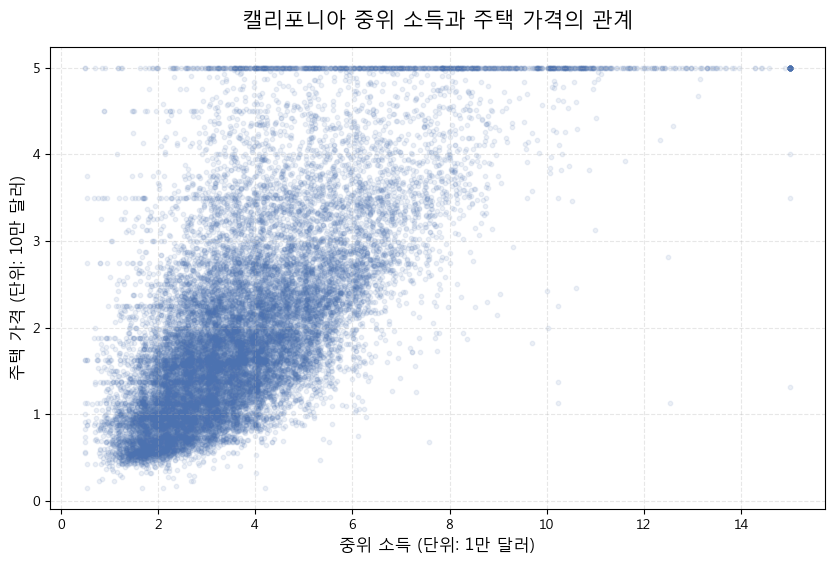

In [27]:
import matplotlib.pyplot as plt

# 1. 폰트 설정 (에러 없는 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 크기 및 생성
plt.figure(figsize=(10, 6))

# 3. 산점도 그리기
# s=10: 점 크기를 작게 해서 뭉침 현상 방지
# alpha=0.1: 투명도 조절로 밀집 지역 확인
# color='#4C72B0': 차분한 네이비 블루 계열
plt.scatter(df['MedInc'], df['Price'], alpha=0.1, s=10, color='#4C72B0')

# 4. 축 이름 및 제목 설정
plt.title('캘리포니아 중위 소득과 주택 가격의 관계', fontsize=15, pad=15)
plt.xlabel('중위 소득 (단위: 1만 달러)', fontsize=12)
plt.ylabel('주택 가격 (단위: 10만 달러)', fontsize=12)

# 5. 보조선(격자) 추가 (흐리게)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

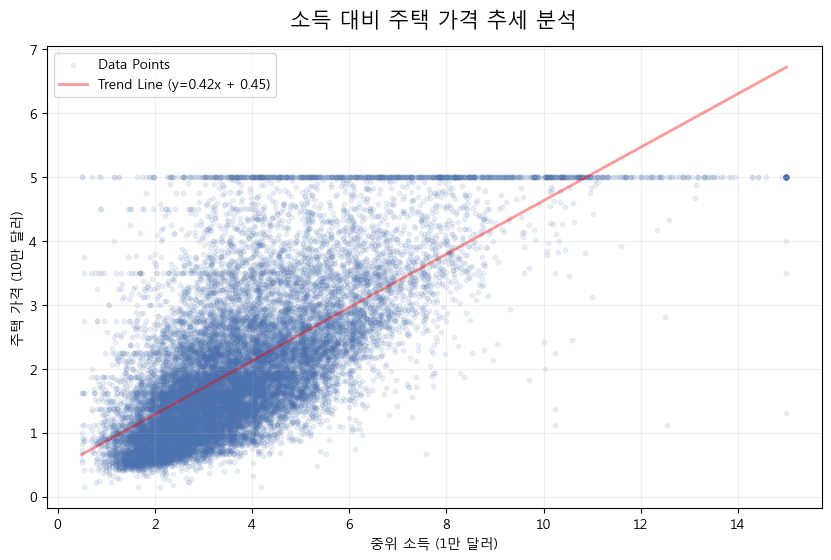

기울기(a): 0.4179 -> 소득이 1단위 오를 때 집값은 약 4.2만 달러 오름


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 폰트 및 그래프 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 6))

# 2. 산점도 (아까와 동일하게 alpha=0.1)
plt.scatter(df['MedInc'], df['Price'], alpha=0.1, s=10, color='#4C72B0', label='Data Points')

# 3. 추세선 계산 (1차 함수 기울기 a와 절편 b 구하기)
# np.polyfit(x, y, 차수)
a, b = np.polyfit(df['MedInc'], df['Price'], 1)

# 4. 추세선 그리기
# x축 범위를 정해서 y값을 계산함
x_line = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 100)
y_line = a * x_line + b

# 추세선은 눈에 잘 띄도록 투명도 없이 빨간색 실선으로!
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Trend Line (y={a:.2f}x + {b:.2f})', alpha=0.4)

# 5. 마무리 꾸미기
plt.title('소득 대비 주택 가격 추세 분석', fontsize=15, pad=15)
plt.xlabel('중위 소득 (1만 달러)')
plt.ylabel('주택 가격 (10만 달러)')
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

print(f"기울기(a): {a:.4f} -> 소득이 1단위 오를 때 집값은 약 {a*10:.1f}만 달러 오름")

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. 모든 피처(8개)를 X에 담고, 가격을 y에 담기
X_all = df.drop('Price', axis=1) 
y = df['Price']

# 2. 데이터 나누기 (학습용 8 : 테스트용 2)
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# 3. 모델 생성 및 학습 (여기서 model_all이 탄생합니다!)
model_all = LinearRegression()
model_all.fit(X_train, y_train)

# 4. 이제 질문하신 코드를 실행하면 에러가 안 납니다.
single_home = X_test.iloc[[0]] 
actual_price = y_test.iloc[0]
predicted_price = model_all.predict(single_home)

print(f"--- 8개 피처를 모두 사용한 결과 ---")
print(f"이 동네 실제 집값: 약 {actual_price*10:.1f}만 달러")
print(f"모델이 예측한 값: 약 {predicted_price[0]*10:.1f}만 달러")

--- 8개 피처를 모두 사용한 결과 ---
이 동네 실제 집값: 약 4.8만 달러
모델이 예측한 값: 약 7.2만 달러


### 📊 데이터 파악 필수 명령어 TOP 10 (Pandas Cheat Sheet)

| 순위 | 명령어 | 용도 (무엇을 알 수 있나?) | 간단 사용법 및 팁 |
| :--- | :--- | :--- | :--- |
| **1** | **`df.head()`** | **데이터의 첫인상** | `df.head(5)` : 상위 5개 행을 보여줍니다. |
| **2** | **`df.info()`** | **데이터의 건강 상태** | 결측치(Null)와 데이터 타입(int, float, object) 확인 필수! |
| **3** | **`df.describe()`** | **수치 데이터의 요약** | 평균, 최솟값, 최댓값 등 통계치를 한눈에 확인합니다. |
| **4** | **`df.shape`** | **데이터의 덩치** | `(행, 열)`의 개수를 즉시 확인합니다. (괄호 없음) |
| **5** | **`df.isnull().sum()`** | **구멍 난 데이터 찾기** | 각 컬럼별로 비어있는 값(NaN)이 몇 개인지 합산합니다. |
| **6** | **`df.corr()`** | **변수 간의 관계(상관성)** | `-1`에서 `1` 사이의 숫자로 상관관계를 파악합니다. |
| **7** | **`df.columns`** | **컬럼 이름 목록** | 어떤 피처(Feature)들이 있는지 리스트 형태로 보여줍니다. |
| **8** | **`df['컬럼'].value_counts()`** | **항목별 빈도 세기** | 범주형 데이터(도시, 성별 등)의 개수를 셀 때 사용합니다. |
| **9** | **`df['컬럼'].unique()`** | **중복 없는 종류 확인** | 특정 컬럼에 어떤 종류의 값들이 들어있는지 확인합니다. |
| **10** | **`df.tail()`** | **데이터의 끝부분** | 마지막 데이터들을 보며 로드 상태를 최종 확인합니다. |

---

### 💡 실전 분석 루틴 (Code Snippet)
```python
# 데이터 로드 직후 아래 코드를 실행하여 성격을 파악하세요.
print(f"1. 데이터 모양: {df.shape}")
print(f"2. 결측치 확인:\n{df.isnull().sum()}")
print("\n3. 기술 통계 요약:")
display(df.describe().round(2))